<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>

# __Embeddings__



## **Introduction**

You work for a streaming service that wants an automatic way to decide whether a movie should be added to its catalog. Each film is expensive to purchase, so the service wants to identify good movies before adding them. You have been hired to build a neural network that predicts whether a movie is good based on written critic reviews, similar to reviews on Rotten Tomatoes.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module4/L1/movie_review.webp" style="width: 60%">

To use text in a neural network, we first need to convert words into numbers. The image below shows the main workflow. First, raw text is split into tokens, such as words. Each token is then mapped to an integer ID using a vocabulary. For example, the sentence `I love cats` becomes a sequence of token IDs.

Next, an **embedding layer** looks up each token ID in an embedding matrix. Instead of using a very large sparse one-hot vector, the embedding layer returns a smaller dense vector for each word. This reduces the dimension from the vocabulary size $V$ to an embedding dimension $D$, where $D$ is much smaller than $V$.

The image also shows why embeddings are useful. Words with similar meanings can have similar vectors and appear close together in the embedding space. For example, words about people, animals, or vehicles can form nearby groups. In this lab, you will learn how to tokenize text, use embedding layers, and train a neural network for sentiment analysis.

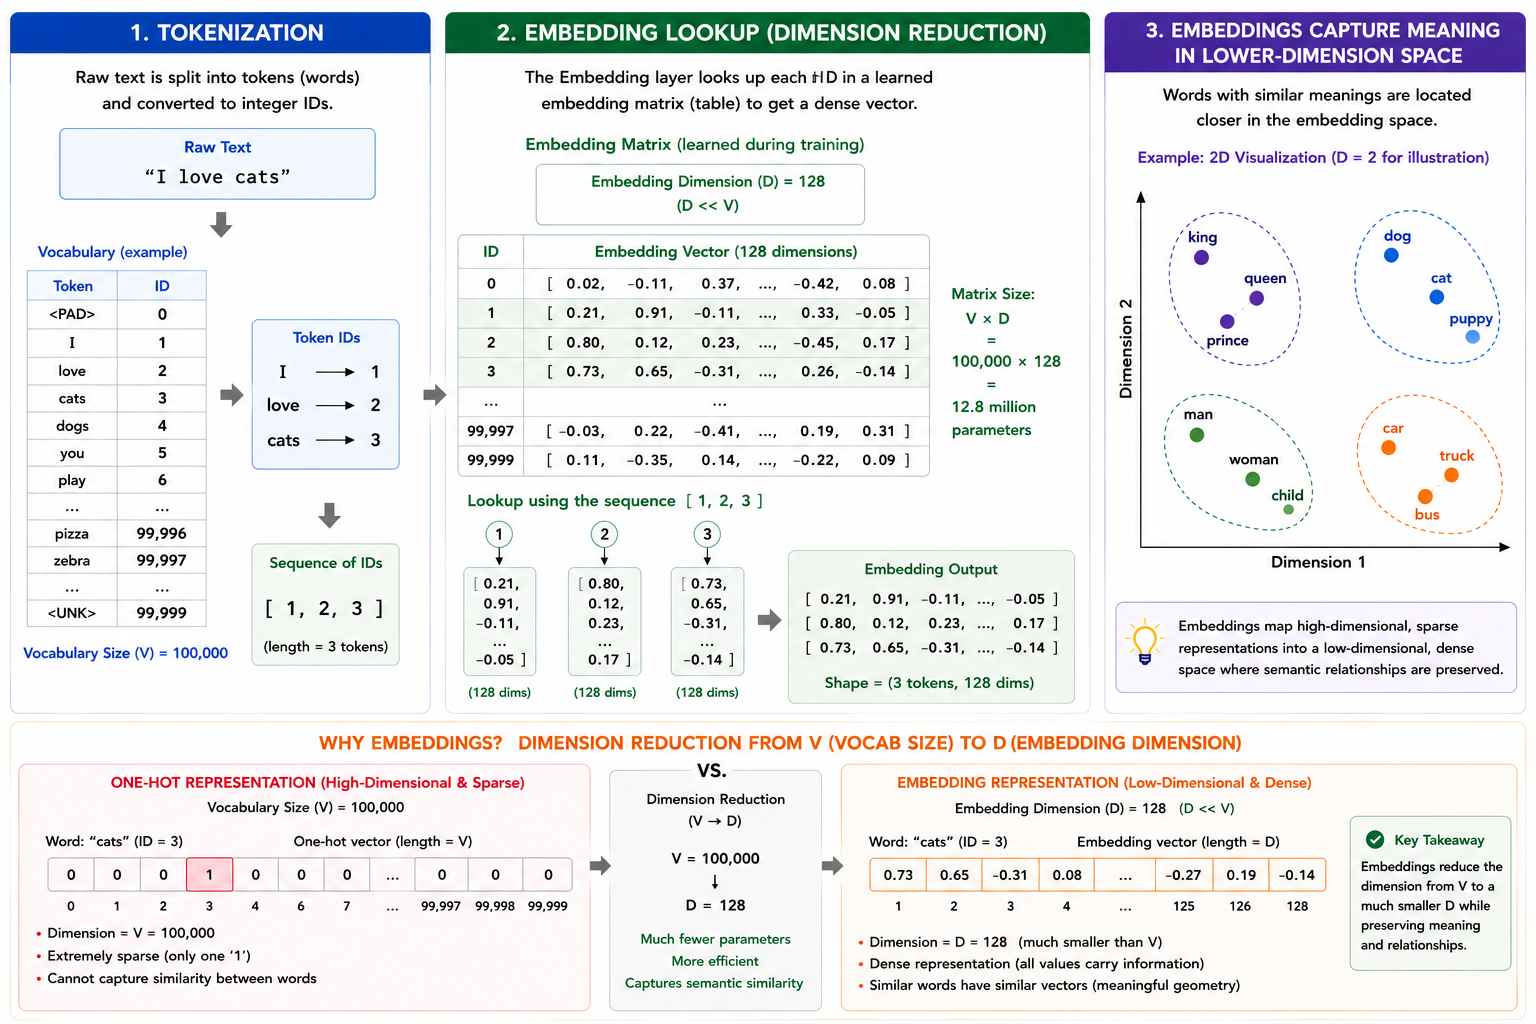


## **Objectives**

After completing this lab, you will be able to:

 - Understand the theory behind Embedding Layers  
 - Apply Tokenizer, Embedding Layers to a neural network 
 - Perform Sentiment Analysis using a neural network 


----


## **Setup**

For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### **Installing Required Libraries**

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run these notebook commands in a different Jupyter environment (like Watson Studio or Ananconda), you will need to install these libraries by removing the `#` sign before `!mamba` in the corresponding code cell below.


In [1]:
# %%capture
#!pip install --upgrade tensorflow

### **Importing Required Libraries**


In [2]:
def warn(*args, **kwargs):
    pass


import warnings

warnings.warn = warn
warnings.filterwarnings("ignore")

import importlib
import numpy as np

import matplotlib.pyplot as plt
from numpy.random import seed

seed(1)

import tensorflow as tf

tf.random.set_seed(1234)
from tensorflow.keras.layers import Embedding, Dense, Flatten, Dropout
from tensorflow.keras.models import Sequential

from keras import preprocessing
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras import regularizers

tf.config.set_visible_devices([], "GPU")

2026-05-27 18:39:16.221329: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-27 18:39:16.221568: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-27 18:39:16.344720: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-27 18:39:17.952375: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different compu

In [3]:
# Print tensorflow version, should be greater than 2.9.0
print(tf.__version__)

2.20.0


### **Defining Helper Functions**


This function will plot the neural network's loss and accuracy curves from its training history:


In [4]:
def display_metrics(history):

    n = len(history.history["loss"])

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(1, 2, 1)
    ax.plot(range(n), (history.history["loss"]), "r", label="Train Loss")
    ax.plot(
        range(n), (history.history["val_loss"]), "b", label="Validation Loss"
    )
    ax.legend()
    ax.set_title("Loss over iterations")

    ax = fig.add_subplot(1, 2, 2)
    ax.plot(range(n), (history.history["acc"]), "r", label="Train Acc")
    ax.plot(range(n), (history.history["val_acc"]), "b", label="Validation Acc")
    ax.legend(loc="lower right")
    ax.set_title("Accuracy over iterations")

This function will plot word embeddings that have been reduced to two dimensions:


In [5]:
def plot_embedding(X_embedded, start=100, stop=300, sample=10):
    fig, ax = plt.subplots()
    ax.scatter(
        X_embedded[start:stop:sample, 0], X_embedded[start:stop:sample, 1]
    )
    for i in range(start, stop, sample):
        ax.annotate(REVERSE_LOOKUP[i + 1], (X_embedded[i, 0], X_embedded[i, 1]))

This function will convert a probability to a Rotten Tomatoes score:


In [6]:
def rotten_tomato_score(p_yx):
    return ["rotten" if p <= 0.60 else "fresh" for p in p_yx]

##  **Background**


Since most machine learning models require numerical input, text data must be converted into a numerical format. A common approach to achieve this is through encoding.

One-hot encoding represents each unique word in a vocabulary as a binary vector. For instance, in a vocabulary of 10,000 words, each word is represented by a vector of length 10,000, where a '1' is placed at the word's specific index and '0's elsewhere.

Consider the following list of three **sequences**:


In [7]:
samples = ["I hate cats", "the dog is brown and I like cats", "for the"]

We have three **sequences**, and the corresponding number of **word tokens** for each sequence is given by:


1. I hate cats - 3 tokens 

2. the dog is brown and likes cats - 8 tokens

3. for the - 2 tokens




### **Tokenizer**


A tokenizer helps convert text into numbers. Before a neural network can use text, each word must be represented in a numerical form.

One simple method is **one-hot encoding**. In one-hot encoding, each word gets its own position in a vector. The vector is mostly zeros, and the position for the selected word is set to one.

Another related method is **multi-hot encoding**. In multi-hot encoding, one vector represents a whole sentence. Each word that appears in the sentence gets a value of one in the vector.

For the sample sentences below, the vocabulary contains the unique words from `samples`. Each word has its own position in the vector:


<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module4/L1/one_hot.png" height="300">


In this example, the vocabulary has ten unique words, so each vector has ten positions. For the word `I`, only the position for `I` is set to one. All other positions are zero:


<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module4/L1/I.png" height="300" >


For the sentence `I hate cats`, we use multi-hot encoding. The positions for `I`, `hate`, and `cats` are set to one. The positions for words that do not appear in the sentence stay zero:


<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module4/L1/I_hate_cats.png" height="300">


We can also represent the same sentence as three separate one-hot vectors: one for `I`, one for `hate`, and one for `cats`.

In both cases, the vector length is based on the vocabulary size. If the vocabulary is large, these vectors also become large. Next, we will use Keras to create these numeric representations automatically.


### **Embedding Layers**

While one-hot encoding is intuitive, it becomes computationally expensive as the vocabulary grows. For instance, a vocabulary of 10,000 words would require each word to be represented by a vector of size 10,000, where only one element is non-zero. This sparsity leads to high memory consumption and the "curse of dimensionality."

To solve this, we use **Embeddings**. An embedding layer maps each word to a dense vector of a fixed, much smaller size (e.g., 50 or 300 dimensions). Unlike one-hot vectors, these embedding vectors are learned during the training process, allowing the model to capture semantic similarities between words—words with similar meanings will end up closer together in the embedding space.

For example, if we have a vocabulary of words, the model converts the discrete word index into a continuous vector. In the context of our example, the model would look up the learned vectors for "I", "hate", and "cats" to create a representation of the sentence. Conceptually, this is similar to using one-hot vectors to select the correct rows from an embedding matrix:

Lets assume we have the embedding for the vocabulary above, we can represent the vocabulary as a list of parameter vectors $[w_{I}, w_{cats}, w_{the}, w_{hate}, w_{dog}, w_{is}, w_{brown},w_{and}, w_{like }, w_{for} ] $ .   

Thus, we can obtain the embedding for the sentence **"I hate cats"** by first performing one-hot-encoding for each token (as shown on the right) and then performing the matrix multiplication with the parameter vectors on the left: 

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module4/L1/Ihat_cats_embeding.png" height="400">


**1. The math idea behind embeddings.** \
    The mathematical process involves representing the input as a set of one-hot encoded vectors. When these are multiplied by the embedding matrix, the result is a single vector for each word. For example, a sentence with three words can be represented as three one-hot-encoded column vectors. After multiplying these vectors by the embedding matrix, the result has shape `1 x 3`, which means `output dimension x input length`. Keras may show this result in a transposed form. Here, the input length is the number of words in the sentence, which is `3`. The output dimension is `1`, so each word is represented by one number.
This example shows the mathematical idea of embeddings.

**2. What Keras actually does in code.** \
    In practice, creating one-hot encoded vectors for every word is computationally expensive. Instead, Keras uses an **Embedding layer**, which acts as a lookup table. It maps each word index directly to its corresponding vector in the embedding matrix, significantly improving efficiency.  The embedding weights start with random values and are updated during model training, just like other neural network weights:


<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module4/L1/I_hate_cats_embeding.png" width="800">


## **Tokenizer in Keras**


Keras has a helper called `Tokenizer`. The `Tokenizer` is used to convert text into a numerical format. It does this by first building a vocabulary of unique words and then mapping each word to an integer.

The process is governed by several key parameters:

- `num_words`: Limits the vocabulary to the most frequent words.

- `filters`: Specifies characters (like punctuation) to be removed.

- `lower`: Determines if the text should be converted to lowercase.

- `split`: Defines the string used to split the text into tokens.

Once the vocabulary is established, the tokenizer can transform raw text into sequences of integers, which can then be fed into an embedding layer or a model. For example:

- `texts_to_matrix(...)`: creates matrix/vector encodings, such as one-hot-like or multi-hot representations.

- `texts_to_sequences(...)`: creates integer sequences, which are usually used before an `Embedding` layer.


We create the ```Tokenizer``` object:

In [8]:
tokenizer = Tokenizer(num_words=11)

#### **`tokenizer.fit_on_texts()`**
Creating the tokenizer is not enough. At this point, it has not seen our text yet.

`fit_on_texts(samples)` lets the tokenizer read the sample sentences. This method only builds the tokenizer's internal vocabulary. It counts the words, ranks them, and assigns each word an integer index.
```text
word_counts  -> how many times each word appears
word_index   -> integer ID for each word
index_word   -> reverse mapping from ID back to word
```
after fitting:
```text
I     -> 1
cats  -> 2
the   -> 3
hate  -> 4
```

`fit_on_texts(...)` does **not** create one-hot vectors, multi-hot vectors, or integer sequences as output. Those are created later, when we call methods such as `texts_to_matrix(...)` or `texts_to_sequences(...)`.


In [9]:
tokenizer.fit_on_texts(samples)

Now we can inspect what the tokenizer learned.

`word_counts` shows each word and how many times it appears in `samples`. For example, `i`, `cats`, and `the` each appear twice, while words like `hate`, `dog`, and `brown` appear once.


In [10]:
word_counts = tokenizer.word_counts
word_counts

OrderedDict([('i', 2),
             ('hate', 1),
             ('cats', 2),
             ('the', 2),
             ('dog', 1),
             ('is', 1),
             ('brown', 1),
             ('and', 1),
             ('like', 1),
             ('for', 1)])

#### **`tokenizer.texts_to_matrix()`**
`texts_to_matrix` is one possible conversion method after `fit_on_texts(...)`.

It converts text into a fixed-length vector and creates one-hot-like or multi-hot matrix/vector representations.

Each position in the vector represents one word position from the tokenizer. In the default `binary` mode, a value of `1` means the word appears in the input text. A value of `0` means the word does not appear.

In the next cell, we pass one word at a time into `texts_to_matrix`. Since each input contains only one word, each output has only one active position. This looks like one-hot encoding and helps us see which vector position belongs to each word.


In [11]:
for key in tokenizer.word_counts.keys():

    print(key)
    print(tokenizer.texts_to_matrix([key]))

i
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
hate
[[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]
cats
[[0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]
the
[[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]
dog
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]
is
[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]
brown
[[0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]]
and
[[0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]
like
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]
for
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


Next, we pass full sentences into `texts_to_matrix`. This is the multi-hot encoding example.

For each sentence, the output is still one fixed-length vector. If several words from the vocabulary appear in the sentence, several positions are set to `1`. If a word does not appear, its position stays `0`.

The vector length is `11` because we created the tokenizer with `num_words=11`. Position `0` is reserved by Keras, so the visible word indexes start after that reserved position.

This matrix form is useful for understanding one-hot and multi-hot encoding. However, it is not the usual input format for an `Embedding` layer.


In [12]:
for sample in samples:

    print(sample)
    print(tokenizer.texts_to_matrix([sample]))

I hate cats
[[0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0.]]
the dog is brown and I like cats
[[0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0.]]
for the
[[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1.]]


`texts_to_matrix` can store different kinds of values. We control this with the `mode` parameter.

`binary`: stores `1` if the word appears, otherwise `0`.

`count`: stores how many times the word appears.

`tfidf`: gives a higher value to words that are more useful for distinguishing one sentence from another.

`freq`: stores the word count as a fraction of the sentence length.

The next cell prints the same sentences using each mode so we can compare the outputs.


In [13]:
modes = ["binary", "count", "tfidf", "freq"]
for mode in modes:
    print("mode:", mode)
    for sample in samples:

        print(sample)
        print(tokenizer.texts_to_matrix([sample], mode=mode))

mode: binary
I hate cats
[[0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0.]]
the dog is brown and I like cats
[[0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0.]]
for the
[[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1.]]
mode: count
I hate cats
[[0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0.]]
the dog is brown and I like cats
[[0. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0.]]
for the
[[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1.]]
mode: tfidf
I hate cats
[[0.         0.69314718 0.69314718 0.         0.91629073 0.
  0.         0.         0.         0.         0.        ]]
the dog is brown and I like cats
[[0.         0.69314718 0.69314718 0.69314718 0.         0.91629073
  0.91629073 0.91629073 0.91629073 0.91629073 0.        ]]
for the
[[0.         0.         0.         0.69314718 0.         0.
  0.         0.         0.         0.         0.91629073]]
mode: freq
I hate cats
[[0.         0.33333333 0.33333333 0.         0.33333333 0.
  0.         0.         0.         0.         0.        ]]
the dog is brown and I like cats
[[0.    0.125 0.125 0.125 0.    0.125 0.12

#### **`tokenizer.texts_to_sequences()`**

So far, `texts_to_matrix()` showed us vector-based encodings such as one-hot-like and multi-hot representations. These are useful to understand how words can be represented, but they are not the usual input for an `Embedding` layer.

For an `Embedding` layer, we usually use integer sequences. To create them, we call `texts_to_sequences()` on the original text.

`texts_to_sequences()` replaces each word with the integer ID learned by the tokenizer. For example, `I hate cats` becomes `[1, 4, 2]`:

`I -> 1`, `hate -> 4`, `cats -> 2`

The `Embedding` layer then uses each integer ID to look up the dense vector for that word. We are not converting one-hot or multi-hot vectors into integer sequences; we are choosing integer sequences as a separate, more suitable representation for embeddings.


In [14]:
for sample in samples:

    print(sample)
    print(tokenizer.texts_to_sequences([sample]))

I hate cats
[[1, 4, 2]]
the dog is brown and I like cats
[[3, 5, 6, 7, 8, 1, 9, 2]]
for the
[[10, 3]]


For an `Embedding` layer, the usual flow is:
```text
raw text
-> fit tokenizer
-> texts_to_sequences
-> Embedding layer
```



### **Input Dimension**


This section uses a tiny toy example to show how an `Embedding` layer works.

In the previous section, `texts_to_sequences()` converted words into integer IDs. For example, a sentence might become `[1, 4, 2]`. The `Embedding` layer receives those integer IDs and looks up a vector for each one.

- `input_dim` (**Vocabulary size**) tells the `Embedding` layer how many possible IDs it may receive. In a real text model, `input_dim` is usually the vocabulary size. This represents the total number of unique words in your dataset. If you have 10,000 unique words, your `input_dim` is 10,000. In a traditional "one-hot encoding" system, each word would be a vector of 10,000 elements (9,999 zeros and one single 1). This is called a **sparse representation**.

- `output_dim` (**Embedding Size**): This is the size of the dense vector you choose (e.g., 50, 100, or 300). Instead of 10,000 numbers, each word is now represented by just 50 numbers. This is a **dense representation**.

| Parameter | What it represents | Simple Analogy | Example Value | Impact on Model |
| :--- | :--- | :--- | :--- | :--- |
| **`input_dim`** | **Vocabulary Size**: The total number of unique tokens in your dataset. | The number of entries in a dictionary. | `10000` | Determines the number of **rows** in the embedding matrix. |
| **`input_length`** | **Sequence Length**: The number of tokens in each input sample (sentence). | The number of words in a single sentence. | `50` | Determines the **width** of the input tensor. |
| **`output_dim`** | **Embedding Dimension**: The size of the vector used to represent each token. | The number of "features" used to describe a word. | `128` | Determines the number of **columns** in the embedding matrix. |

In the next example, the only valid IDs are `0`, `1`, and `2`, so we set `input_dim=3`. 

We set `output_dim=1`, so each ID returns one number. 

In this example, we add an explicit `Input` layer before the `Embedding` layer. This builds the model before we inspect or manually set its weights. `shape=(None,)` means each sample can contain any number of integer IDs. This lets us try both one-ID samples and longer ID sequences.


In [15]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras import Input

import numpy as np

model = Sequential()

input_dim = 3
output_dim = 1
input_length = 1
model.add(Input(shape=(None,), dtype="int32"))
model.add(Embedding(input_dim=input_dim, output_dim=output_dim))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 1)        │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)


Think of a **one-hot vector** (e.g., `[0, 1, 0]`) as a **set of switches**. Since you are multiplying by either $0$ or $1$, the $0$ effectively "turn off" the rows they touch, and the $1$ "lets through" the specific row it is aligned with.

**The Weight Matrix (The Lookup Table):**
In this example, we have a vocabulary of 3 words, each represented by a 1-dimensional vector.

| Index | Vector (Weights) |
| :--- | :--- |
| **Row 0** | `[0]` |
| **Row 1** | `[1]` |
| **Row 2** | `[2]` |

ID 0: The first switch is ON
* **One-hot vector:** `[1, 0, 0]`
* **Math:**
$$ \begin{bmatrix} 1 & 0 & 0 \end{bmatrix} \times \begin{bmatrix} 0 \\ 1 \\ 2 \end{bmatrix} = [0] $$
* **Result:** The `1` is in the first position, so it selects **Row 0**.

ID 1: The second switch is ON
* **One-hot vector:** `[0, 1, 0]`
* **Math:**
$$ \begin{bmatrix} 0 & 1 & 0 \end{bmatrix} \times \begin{bmatrix} 0 \\ 1 \\ 2 \end{bmatrix} = [1] $$
* **Result:** The `1` is in the second position, so it selects **Row 1**.

ID 2: The third switch is ON
* **One-hot vector:** `[0, 0, 1]`
* **Math:**
$$ \begin{bmatrix} 0 & 0 & 1 \end{bmatrix} \times \begin{bmatrix} 0 \\ 1 \\ 2 \end{bmatrix} = [2] $$
* **Result:** The `1` is in the third position, so it selects **Row 2**.

The mathematical operation of multiplying a one-hot vector by a matrix is just a fancy way of saying: 
> **"Go to the row number that matches the position of the 1."**

In actual libraries like TensorFlow or PyTorch, the computer **does not** perform this matrix multiplication because it is computationally expensive. Instead, it performs a **direct lookup** (like looking up a word in a dictionary), because the mathematical result is guaranteed to be the same.

In [16]:
model.get_weights()
weights = np.array([0, 1, 2]).reshape(-1, 1)

model.set_weights([weights])
model.get_weights()

[array([[0.],
        [1.],
        [2.]], dtype=float32)]

Now we pass one integer ID at a time into the embedding layer. The layer uses the ID to select the matching row from the embedding table.

Because we set the weights manually, the output is easy to check: ID `0` returns `0`, ID `1` returns `1`, and ID `2` returns `2`.


In [17]:
for n in range(3):
    x = np.array([[n]])
    print("input x={}".format(n))
    z = model.predict(x)
    print("output z={}".format(z.tolist()))

input x=0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
output z=[[[0.0]]]
input x=1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
output z=[[[1.0]]]
input x=2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
output z=[[[2.0]]]


We can also pass more than one ID at a time. The shape of the input changes how Keras groups the IDs.

`np.array([[0], [1], [2]])` means three separate samples. Each sample contains one ID.

`np.array([[0, 1, 2]])` means one sample. That one sample contains a sequence of three IDs.

This is similar to a tokenized sentence: one sentence is one sequence of word IDs.


In [18]:
z = model.predict(np.array([[0], [1], [2]]))
print("different samples in the batch dimension:\n", z)
z = model.predict(np.array([[0, 1, 2]]))
print(" multiple samples in a row: \n", z)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
different samples in the batch dimension:
 [[[0.]]

 [[1.]]

 [[2.]]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
 multiple samples in a row: 
 [[[0.]
  [1.]
  [2.]]]


### **Output shape**

In practice, the "output dimension" of an embedding layer defines the size of the vector used to represent each token. For example, if `output_dim` is 50, each word is converted into a list of 50 numbers. These numbers are "learned" during training. 

In the next example, the valid IDs are `0`, `1`, `2`, and `3`, so we set `input_dim=4`. We set `output_dim=2`, so each ID returns a two-number vector.




In [19]:
input_dim = 4
output_dim = 2
input_length = 1
model = Sequential()
model.add(Input(shape=(input_length,), dtype="int32"))
model.add(Embedding(input_dim=input_dim, output_dim=output_dim))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 1, 2)           │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (32.00 B)

 Trainable params: 8 (32.00 B)

 Non-trainable params: 0 (0.00 B)

Here is the small embedding table we create by hand. Think of it as a lookup table with four rows:

ID `0` looks up row `[0, 0]`

ID `1` looks up row `[0, 1]`

ID `2` looks up row `[1, 0]`

ID `3` looks up row `[1, 1]`

**Note**: In most neural network layers (like a Dense layer), "weights" are coefficients that multiply an input to produce an output. But in an Embedding layer, the "weights" are the actual embedding vectors themselves. An embedding layer is essentially just a lookup table.


In [20]:
weights = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
model.set_weights([weights])
model.get_weights()

[array([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]], dtype=float32)]

Now we test the lookup. When we input ID `0`, the embedding layer should return `[0, 0]`. When we input ID `1`, it should return `[0, 1]`, and so on.


In [21]:
for n in range(4):
    x = np.array([[n]])
    print("input x={}".format(n))
    z = model.predict(x)
    print("output vector={}".format(z.tolist()))

input x=0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
output vector=[[[0.0, 0.0]]]
input x=1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
output vector=[[[0.0, 1.0]]]
input x=2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
output vector=[[[1.0, 0.0]]]
input x=3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
output vector=[[[1.0, 1.0]]]


This is the main lesson from both examples: an embedding layer is a trainable lookup table.

The input is an integer ID.

The output is the vector stored in the row for that ID.

In real text models, the IDs come from `tokenizer.texts_to_sequences()`, and the embedding vectors are learned during training.


### **Padding Sequences**


Text sequences often have different lengths. One sentence may have three words, while another may have eight words.

First, look at the original text samples and count the words in each sample:


In [22]:
samples = ["I hate cats", "the dog is brown and I like cats", "for the"]
for sample in samples:
    print("sample:", sample)
    print("word count:", len(sample.split()))

sample: I hate cats
word count: 3
sample: the dog is brown and I like cats
word count: 8
sample: for the
word count: 2


After tokenization, the integer sequences also have different lengths. This happens because each sentence has a different number of words:


In [23]:
tokenizer = Tokenizer(num_words=12)
tokenizer.fit_on_texts(samples)
tokens = tokenizer.texts_to_sequences(samples)
print("tokens", tokens)

tokens [[1, 4, 2], [3, 5, 6, 7, 8, 1, 9, 2], [10, 3]]


Neural networks usually expect inputs in a rectangular array. That means each sequence in a batch must have the same length.

`pad_sequences` makes the integer sequences the same length. It returns a 2D NumPy array where each row is one sample and each column is one token position.

`maxlen` sets the final length of each sequence. If a sequence is shorter than `maxlen`, Keras adds padding values. The default padding value is `0`.

Consider the following example:


In [24]:
maxlen = 9
x = pad_sequences(tokens, maxlen=maxlen, value=0)
x

array([[ 0,  0,  0,  0,  0,  0,  1,  4,  2],
       [ 0,  3,  5,  6,  7,  8,  1,  9,  2],
       [ 0,  0,  0,  0,  0,  0,  0, 10,  3]], dtype=int32)

By default, Keras adds padding at the beginning of each sequence. This is called pre-padding.

If we want the padding to appear after the real token IDs, we can use `padding="post"`.


In [25]:
maxlen = 9
x = pad_sequences(tokens, maxlen=maxlen, padding="post")
x

array([[ 1,  4,  2,  0,  0,  0,  0,  0,  0],
       [ 3,  5,  6,  7,  8,  1,  9,  2,  0],
       [10,  3,  0,  0,  0,  0,  0,  0,  0]], dtype=int32)

If `maxlen` is shorter than a sequence, Keras must remove some token IDs. This is called truncation.

In the next example, we set `maxlen=5`, so any sequence longer than five IDs is shortened.


In [26]:
maxlen = 5
x = pad_sequences(tokens, maxlen=maxlen)
x

array([[ 0,  0,  1,  4,  2],
       [ 7,  8,  1,  9,  2],
       [ 0,  0,  0, 10,  3]], dtype=int32)

By default, Keras removes values from the beginning of sequences that are too long. This is called pre-truncation.

If we want to remove values from the end instead, we can use `truncating="post"`.


## **Sentiment Analysis** 


Now we will use integer sequences and an `Embedding` layer to build a simple sentiment classifier.

Sentiment analysis means predicting whether a piece of text expresses a positive or negative opinion. In this section, we use the IMDB movie review dataset. Each review is labeled as either negative or positive.

The IMDB dataset from Keras is already tokenized. That means each review is already stored as a list of integer word IDs. We do not need to create a `Tokenizer` ourselves for this dataset.

The workflow in this section is:

1. Load IMDB reviews that are already integer sequences.
2. Inspect the integer sequences.
3. Pad all reviews to the same length.
4. Pass the padded sequences into an `Embedding` layer.
5. Train a small neural network to predict sentiment.

We keep only the top `10,000` most common words by setting `num_words=10000`.


In [27]:
from keras.datasets import imdb

In [28]:
max_features = 10000

# change the default parameter of np to allow_pickle=True
np.load.__defaults__ = (None, True, True, "ASCII")
importlib.reload(np)

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

Let's print the first three training samples. Each sample is a movie review represented as integer word IDs, not raw text.


In [29]:
for i, x in enumerate(x_train[0:3]):
    print("Sequence:", i)
    print(x)

Sequence: 0
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
Sequence: 1
[1, 194, 1153, 194, 8255, 78, 228, 5

Keras also provides a dictionary that maps each word to its integer ID. We use this dictionary only to inspect the data and convert a few reviews back into readable text.


In [30]:
word_index = imdb.get_word_index()

The original dictionary maps `word -> ID`. To decode reviews, we need the opposite direction: `ID -> word`.

The IMDB dataset reserves a few IDs for special tokens, such as padding and unknown words. The real word IDs are shifted by `INDEX_FROM=3`, so we add that offset when building `REVERSE_LOOKUP`.


In [31]:
INDEX_FROM = 3
REVERSE_LOOKUP = {value + INDEX_FROM: key for key, value in word_index.items()}
REVERSE_LOOKUP[0] = "<PAD>"
REVERSE_LOOKUP[1] = "<START>"
REVERSE_LOOKUP[2] = "<OOV>"
REVERSE_LOOKUP[3] = "<UNUSED>"

The following helper function converts one integer sequence back into words. This is only for inspection. The model itself will still use the integer IDs.


In [32]:
def get_review(x):
    return " ".join([REVERSE_LOOKUP.get(index, "?") for index in x])

Now we decode the first training sample so we can see the review text behind the integer IDs:


In [33]:
get_review(x_train[0])

"<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <OOV> is an amazing actor and now the same being director <OOV> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <OOV> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <OOV> to the two little boy's that played the <OOV> of norman and paul they were just brilliant children are often left out of the <OOV> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for wh

We can decode another sample in the same way:


In [34]:
get_review(x_train[1])

"<START> big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the worst ever made the plot is paper thin and ridiculous the acting is an abomination the script is completely laughable the best is the end showdown with the cop and how he worked out who the killer is it's just so damn terribly written the clothes are sickening and funny in equal <OOV> the hair is big lots of boobs <OOV> men wear those cut <OOV> shirts that show off their <OOV> sickening that men actually wore them and the music is just <OOV> trash that plays over and over again in almost every scene there is trashy music boobs and <OOV> taking away bodies and the gym still doesn't close for <OOV> all joking aside this is a truly bad film whose only charm is to look back on the disaster that was the 80's and have a good old laugh at how bad everything was back then"

Each review can have a different number of word IDs. The next cell prints the sequence length for the first three reviews:


In [35]:
for i, x in enumerate(x_train[0:3]):
    print("length {} of sample {}:".format(i, len(x)))

length 0 of sample 218:
length 1 of sample 189:
length 2 of sample 141:


Neural networks train on batches, and each batch needs a rectangular input array. Therefore, every review must have the same length.

We use `pad_sequences` to make each review exactly `20` IDs long. Reviews longer than `20` IDs are shortened, and reviews shorter than `20` IDs are padded with zeros.


In [36]:
maxlen = 20
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

In [37]:
x_test.shape

(25000, 20)

Now we build the neural network.

`Input(shape=(maxlen,))` means each review has `20` integer IDs after padding.

`Embedding(input_dim=max_features, output_dim=8)` creates a trainable lookup table. It can receive word IDs from `0` to `9999`, and it converts each ID into an 8-number vector.

After the embedding layer, each review has shape `(20, 8)`: 20 token positions, with an 8-number vector for each token.

`Flatten()` turns the `(20, 8)` embedding output into one long vector so a `Dense` layer can use it for classification.


In [38]:
model = Sequential()
model.add(Input(shape=(maxlen,), dtype="int32"))
model.add(Embedding(input_dim=max_features, output_dim=8))
model.add(Flatten())

Next, we add the output layer.

`Dense(1, activation="sigmoid")` returns one number between `0` and `1`. This number is the model's estimated probability for the positive class.

We use `binary_crossentropy` because this is a binary classification task: each review is either negative or positive.


In [39]:
model.add(Dense(1, activation="sigmoid"))
model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["acc"])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 20, 8)          │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,161 (313.13 KB)

 Trainable params: 80,161 (313.13 KB)

 Non-trainable params: 0 (0.00 B)

Now we train the model.

`x_train` contains the padded review sequences, and `y_train` contains the sentiment labels. We train for 10 epochs and reserve 20% of the training data for validation.


In [40]:
history = model.fit(
    x_train, y_train, epochs=10, batch_size=30, validation_split=0.2
)

Epoch 1/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - acc: 0.6038 - loss: 0.6746 - val_acc: 0.6848 - val_loss: 0.6306
Epoch 2/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - acc: 0.7458 - loss: 0.5521 - val_acc: 0.7262 - val_loss: 0.5324
Epoch 3/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - acc: 0.7833 - loss: 0.4676 - val_acc: 0.7420 - val_loss: 0.5066
Epoch 4/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - acc: 0.8051 - loss: 0.4277 - val_acc: 0.7496 - val_loss: 0.5005
Epoch 5/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - acc: 0.8194 - loss: 0.4002 - val_acc: 0.7512 - val_loss: 0.5008
Epoch 6/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 982us/step - acc: 0.8333 - loss: 0.3772 - val_acc: 0.7502 - val_loss: 0.5042
Epoch 7/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - acc: 0.8446 - loss: 0.3562 - val_acc: 0.7484 - val_loss: 0.5096
Epoch 8/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - acc: 0.8570 - loss: 0.3363 - val_acc: 0.7474 - val_loss: 0.5166
Epoch 9/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 920us/step 

After training, we plot the training and validation metrics. This helps us see whether the model is learning and whether it may be overfitting.


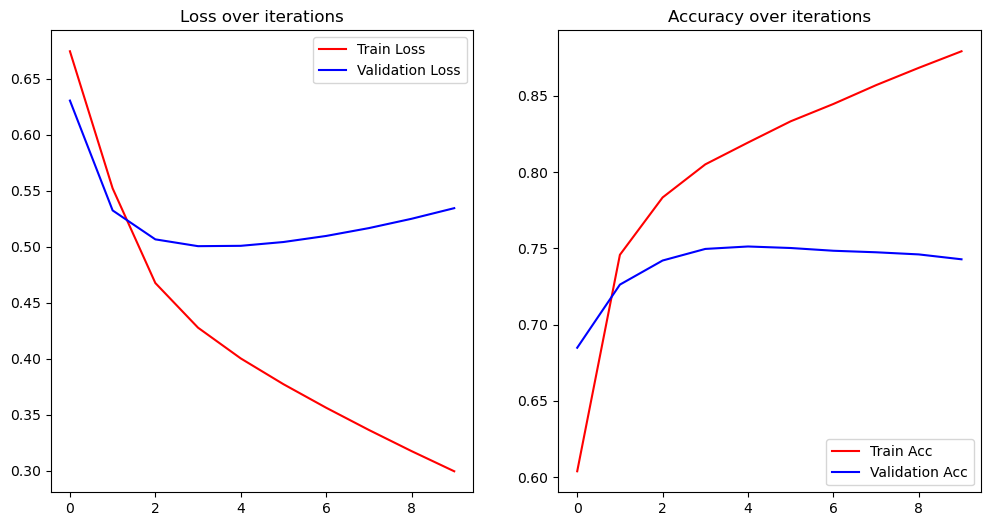

In [41]:
display_metrics(history)

Now we use the model to predict sentiment for the first 10 test reviews.

The model outputs probabilities between `0` and `1`. A value closer to `1` means the model predicts a more positive review. A value closer to `0` means the model predicts a more negative review.


In [42]:
p_yx = model.predict(x_test[0:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


The helper function `rotten_tomato_score` turns those probabilities into readable labels such as `fresh` or `rotten`.


In [43]:
rotten_tomato_score(p_yx)

['rotten',
 'fresh',
 'rotten',
 'fresh',
 'fresh',
 'rotten',
 'rotten',
 'rotten',
 'rotten',
 'rotten']

### **Visualizing the embedding weights**


After training, the embedding layer contains learned vectors for the word IDs. These vectors were adjusted during training to help the model predict sentiment.

The next cell gets the embedding table from the first layer of the model:


In [44]:
weights = model.layers[0].get_weights()[0]

The embedding table has shape `(10000, 8)`.

`10000` means there is one row for each word ID kept by `max_features`.

`8` means each word ID is represented by an 8-number vector.


In [45]:
weights.shape

(10000, 8)

Each embedding vector has 8 numbers, so we cannot directly draw it on a 2D plot.

We use TSNE to reduce each 8-dimensional vector to 2 dimensions. This lets us make a rough visualization of the learned embeddings.


In [46]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2)
X_embedded = tsne.fit_transform(weights)

Now we plot some of the transformed embeddings.

`start` and `stop` choose the range of word IDs to show.

`sample` controls how many IDs we skip between plotted points. A larger `sample` shows fewer words and makes the plot less crowded.


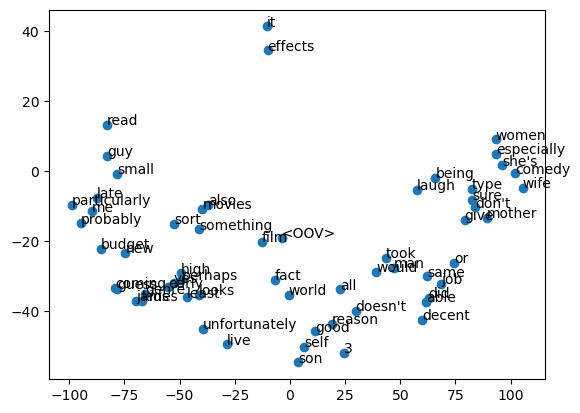

In [47]:
start = 1
stop = 600
sample = 10
plot_embedding(X_embedded, start, stop, sample)

Words that appear near each other in this plot have similar learned embedding vectors. The plot is only a rough visualization, but it can help us inspect whether related words are grouped together after training.


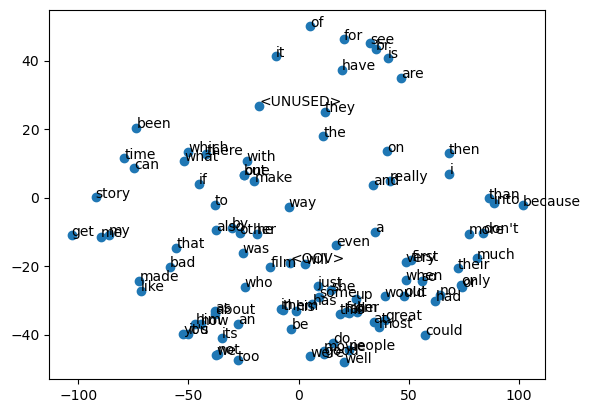

In [48]:
start = 1
stop = 100
sample = 1
plot_embedding(X_embedded, start, stop, sample)

### **Exercise 1** 

Build a larger classifier using the same input pipeline:

1. Start with an `Input` layer for padded review sequences.
2. Add an `Embedding` layer to convert word IDs into vectors.
3. Flatten the embedding output.
4. Add two hidden `Dense` layers: one with 500 neurons and one with 250 neurons.
5. Add a final sigmoid output layer for binary sentiment classification.
6. Train the model and use `display_metrics(history)` to plot the results.


Epoch 1/10


667/667 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.6829 - loss: 0.5692 - val_acc: 0.7294 - val_loss: 0.5335
Epoch 2/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.7934 - loss: 0.4425 - val_acc: 0.7432 - val_loss: 0.5251
Epoch 3/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.8269 - loss: 0.3909 - val_acc: 0.7460 - val_loss: 0.5384
Epoch 4/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.8551 - loss: 0.3403 - val_acc: 0.7386 - val_loss: 0.5666
Epoch 5/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.8861 - loss: 0.2828 - val_acc: 0.7256 - val_loss: 0.6171
Epoch 6/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9158 - loss: 0.2235 - val_acc: 0.7162 - val_loss: 0.7015
Epoch 7/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - acc: 0.9413 - loss: 0.1661 - val_acc: 0.7046 - val_loss: 0.8200
Epoch 8/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9625 - loss: 0.1146 - val_acc: 0.6930 - val_loss: 0.9863
Epoch 9/10
667/667 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9786 -

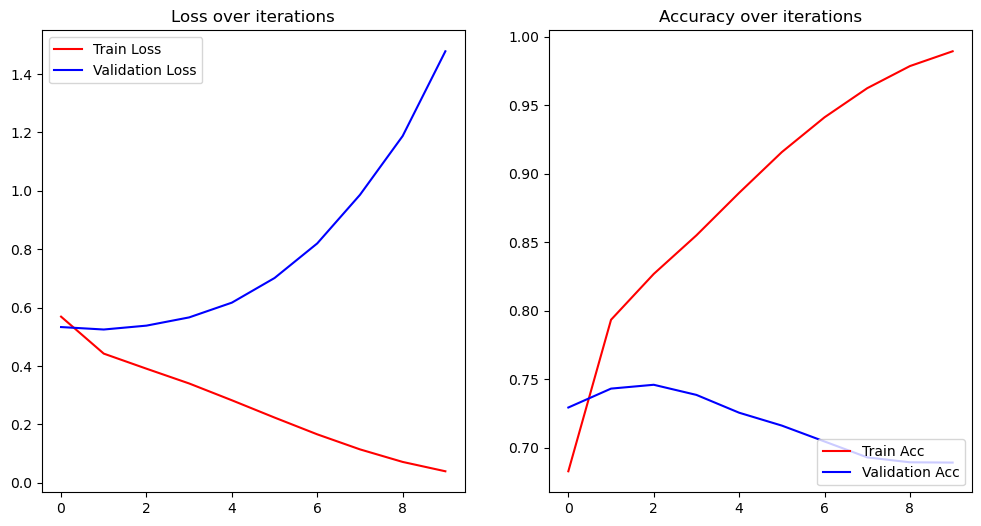

In [49]:
model = Sequential()
model.add(Input(shape=(maxlen,), dtype="int32"))
model.add(Embedding(input_dim=max_features, output_dim=8))
model.add(Flatten())

model.add(Dense(500, activation="relu"))
model.add(Dense(250, activation="relu"))
model.add(Dense(1, activation="sigmoid"))
model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["acc"])
history = model.fit(
    x_train, y_train, epochs=10, batch_size=30, validation_split=0.2
)

display_metrics(history)

<details>
    <summary>Click here for Solution</summary>

```python
model = Sequential()
model.add(Input(shape=(maxlen,), dtype="int32"))
model.add(Embedding(input_dim=max_features, output_dim=8))
model.add(Flatten())

model.add(Dense(500, activation="relu"))
model.add(Dense(250, activation="relu"))
model.add(Dense(1, activation="sigmoid"))
model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["acc"])
history = model.fit(x_train, y_train, epochs=10, batch_size=30, validation_split=0.2)

display_metrics(history)
```
</details>


### **Exercise 2** 

Compare the larger model with the smaller model. Does the larger model perform better on validation data, or does it start to overfit?


The smaller model shows relatively stable learning behavior. Both training loss and validation loss decrease at the beginning, and the validation accuracy improves before leveling off around 75%. After a few epochs, the validation performance stops improving and begins to slightly worsen, which suggests mild overfitting. However, the gap between training and validation performance remains moderate, so the model still generalizes reasonably well to unseen data.

The larger model shows clear and severe overfitting. The training loss becomes extremely low and the training accuracy approaches nearly 100%, which means the model is memorizing the training data very well. However, the validation loss increases sharply and the validation accuracy gradually decreases over time. This indicates that the model is no longer learning general patterns and instead is fitting noise or details specific to the training set. Overall, the smaller model performs better for generalization, while the larger model has too much capacity for the dataset.


<details>
    <summary>Click here for Solution</summary>


The larger model can fit the training data more strongly, but it may not improve validation performance. If training accuracy keeps improving while validation accuracy stops improving or gets worse, the model is overfitting.

</details>


### **Exercise 3** 

Add regularization to reduce overfitting. In this example, we use two common techniques:

`L2` regularization discourages very large weights.

`Dropout` randomly turns off some neurons during training, which helps the model rely less on any single path.


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 20, 8)          │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 500)            │        80,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 286,001 (1.09 MB)

 Trainable params: 286,001 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.5018 - loss: 0.9373 - val_acc: 0.4938 - val_loss: 0.6933
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.5002 - loss: 0.6933 - val_acc: 0.4938 - val_loss: 0.6933
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.5022 - loss: 0.6932 - val_acc: 0.4938 - val_loss: 0.6932
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.5030 - loss: 0.6932 - val_acc: 0.4938 - val_loss: 0.6933
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.4998 - loss: 0.6932 - val_acc: 0.4938 - val_loss: 0.6933
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.4983 - loss: 0.6932 - val_acc: 0.4938 - val_loss: 0.6932
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.4976 - loss: 0.6932 - val_acc: 0.4938 - val_loss: 0.6933
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.4967 - loss: 0.6932 - val_acc: 0.4938 - val_loss: 0.6933
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - ac

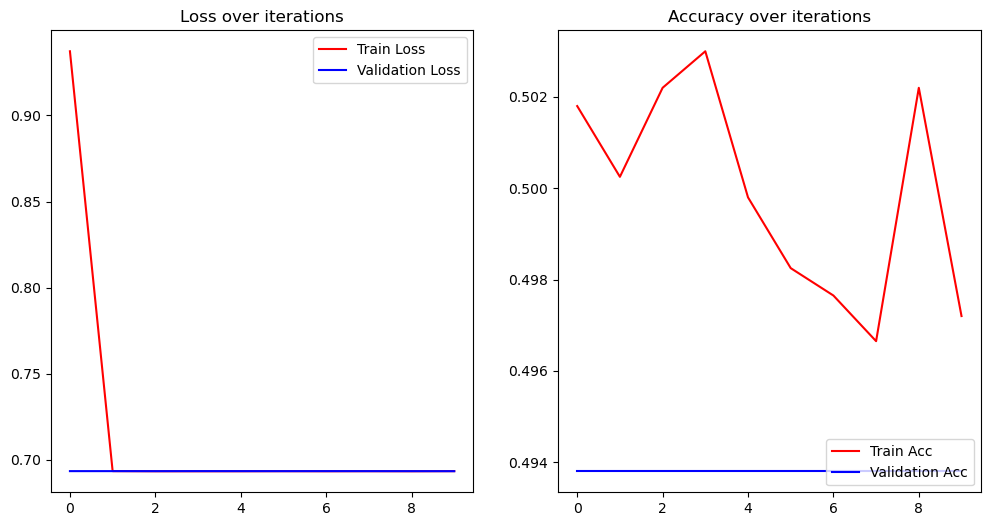

In [50]:
# Enter your solution here
model = Sequential()
model.add(Input(shape=(maxlen,), dtype="int32"))
model.add(Embedding(input_dim=max_features, output_dim=8))
model.add(Flatten())
model.add(
    Dense(
        500,
        kernel_initializer="normal",
        activation="relu",
        kernel_regularizer=regularizers.L2(l2=5e-3),
    )
)
model.add(Dropout(0.4))

model.add(
    Dense(
        250,
        kernel_initializer="normal",
        activation="relu",
        kernel_regularizer=regularizers.L2(l2=5e-3),
    )
)
model.add(Dropout(0.3))
model.add(Dense(1, activation="sigmoid"))
model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["acc"])
model.summary()

history = model.fit(
    x_train, y_train, epochs=10, batch_size=64, validation_split=0.2
)
display_metrics(history)

The large model with regularization no longer shows severe overfitting, but it now appears to be underfitting. Both training and validation accuracy remain around 50% and do not improve during training, while the losses stay almost constant after the first epoch. This suggests that the regularization is too strong, preventing the model from learning useful patterns from the data. In this case, the model is no longer memorizing the training set, but it is also not learning enough to make accurate predictions. A better balance between model capacity and regularization is needed.

<details>
    <summary>Click here for Solution</summary>

```python
model = Sequential()
model.add(Input(shape=(maxlen,), dtype="int32"))
model.add(Embedding(input_dim=max_features, output_dim=8))
model.add(Flatten())
model.add(Dense(500, kernel_initializer="normal", activation="relu", kernel_regularizer=regularizers.L2(l2=5e-3)))
model.add(Dropout(0.4))

model.add(Dense(250, kernel_initializer="normal", activation="relu", kernel_regularizer=regularizers.L2(l2=5e-3)))
model.add(Dropout(0.3))
model.add(Dense(1, activation="sigmoid"))
model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["acc"]) 
model.summary()

history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)
display_metrics(history)
```
</details>


## **Author**


[Joseph Santarcangelo](https://www.linkedin.com/in/david-pasternak-6b84a2208/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera747-2022-01-01)

Su Wu



## **Change Log**

| Date (YYYY-MM-DD) | Version | Changed By | Change Description                 |
| ----------------- | ------- | ---------- | ---------------------------------- |
| 2022-03-28        | 0.1     | David Pasternak      | Created Lab    |
| 2022-05-10        | 0.2     | Sam Prokopchuk      | Complete Draft of Lab    |
| 2022-08-10        | 0.2     | Roxanne Li      | Review and edit Lab    |
| 2022-09-08        | 0.2     | Steve Hord      | QA pass and edits      |
|2026-05-26 | Student modification |Su Wu | Added explanatory documentation, code comments, and minor code edits for coursework, learning, and portfolio development|

## <h3 align="center"> © IBM Corporation 2022. All rights reserved. <h3/>
